In [18]:
import os

print("Jupyter is looking in:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Jupyter is looking in:
C:\Users\shash\Downloads\Predictive_Analytics_Superstore

Files in this folder:
['.ipynb_checkpoints', 'archive (3)', 'archive (3).zip', 'Sales_Forecasting.ipynb']


In [19]:
import os

print(os.listdir("archive (3)"))

['.ipynb_checkpoints', 'Sample - Superstore.csv']


In [21]:
import pandas as pd

df = pd.read_csv(
    "archive (3)/Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [22]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9994, 21)


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [24]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [27]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [30]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [31]:
total_sales = df['Sales'].sum()

print("Total Sales:", total_sales)

Total Sales: 2297200.8603


In [32]:
total_profit = df['Profit'].sum()

print("Total Profit:", total_profit)

Total Profit: 286397.0217


In [33]:
total_quantity = df['Quantity'].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 37873


In [34]:
print("Start Date:", df['Order Date'].min())
print("End Date:", df['Order Date'].max())

Start Date: 2014-01-03 00:00:00
End Date: 2017-12-30 00:00:00


In [35]:
monthly_sales = df.resample(
    'ME',
    on='Order Date'
)['Sales'].sum()

In [36]:
monthly_sales.head()

Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

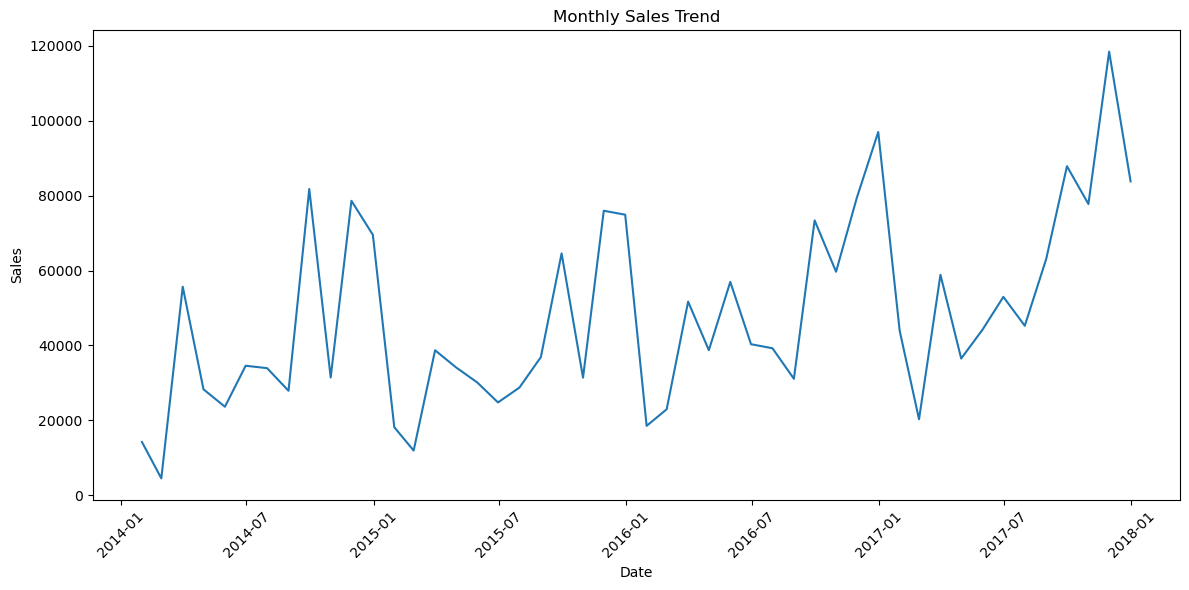

In [37]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
data = monthly_sales.reset_index()

data.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [40]:
data.columns

Index(['Order Date', 'Sales'], dtype='object')

In [41]:
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month
data['Quarter'] = data['Order Date'].dt.quarter
data['Time_Index'] = np.arange(len(data))

In [42]:
data.head()

,Order Date,Sales,Year,Month,Quarter,Time_Index
0,2014-01-31,14236.895,2014,1,1,0
1,2014-02-28,4519.892,2014,2,1,1
2,2014-03-31,55691.009,2014,3,1,2
3,2014-04-30,28295.345,2014,4,2,3
4,2014-05-31,23648.287,2014,5,2,4


In [43]:
X = data[['Year', 'Month', 'Quarter', 'Time_Index']]
y = data['Sales']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48, 4)
y shape: (48,)


In [44]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 38
Testing data: 10


In [45]:
from sklearn.ensemble import RandomForestRegressor

In [46]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [47]:
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
y_pred = model.predict(X_test)

print(y_pred)

[43577.594084  40712.4139915 42738.6155735 38580.120742  36084.5828885
 35324.3147865 74884.65388   68371.3584215 88830.2757545 89536.54967  ]


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [50]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

In [51]:
print("Model Performance")
print("------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Performance
------------------
MAE : 13009.848553100013
RMSE: 15763.580706197241
R²  : 0.5623318196816414


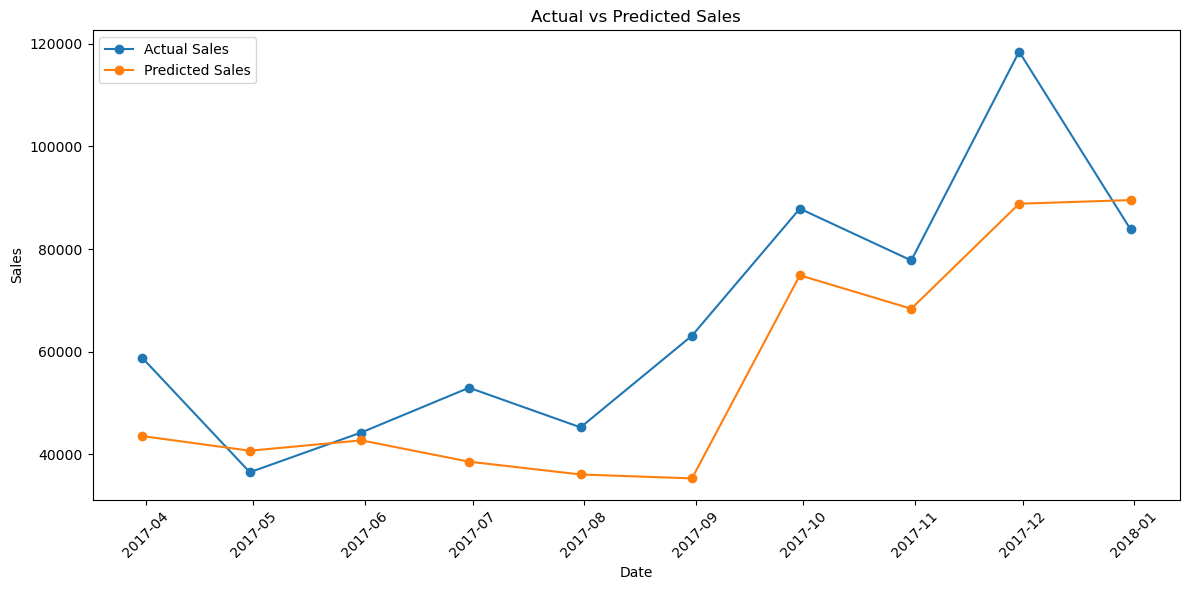

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(
    data['Order Date'].iloc[split:],
    y_test.values,
    marker='o',
    label='Actual Sales'
)

plt.plot(
    data['Order Date'].iloc[split:],
    y_pred,
    marker='o',
    label='Predicted Sales'
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [53]:
# Create dates for the next 6 months

last_date = data['Order Date'].max()

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthEnd(1),
    periods=6,
    freq='ME'
)

future = pd.DataFrame({
    'Order Date': future_dates
})

# Create the same features used by the model
future['Year'] = future['Order Date'].dt.year
future['Month'] = future['Order Date'].dt.month
future['Quarter'] = future['Order Date'].dt.quarter
future['Time_Index'] = np.arange(
    len(data),
    len(data) + 6
)

# Predict future sales
future['Predicted Sales'] = model.predict(
    future[['Year', 'Month', 'Quarter', 'Time_Index']]
)

future

,Order Date,Year,Month,Quarter,Time_Index,Predicted Sales
0,2018-01-31,2018,1,1,48,31902.922310
1,2018-02-28,2018,2,1,49,26257.173553
2,2018-03-31,2018,3,1,50,43577.594084
3,2018-04-30,2018,4,2,51,40712.413992
4,2018-05-31,2018,5,2,52,42738.615574
5,2018-06-30,2018,6,2,53,38580.120742


In [54]:
future[['Order Date', 'Predicted Sales']]

,Order Date,Predicted Sales
0,2018-01-31,31902.922310
1,2018-02-28,26257.173553
2,2018-03-31,43577.594084
3,2018-04-30,40712.413992
4,2018-05-31,42738.615574
5,2018-06-30,38580.120742


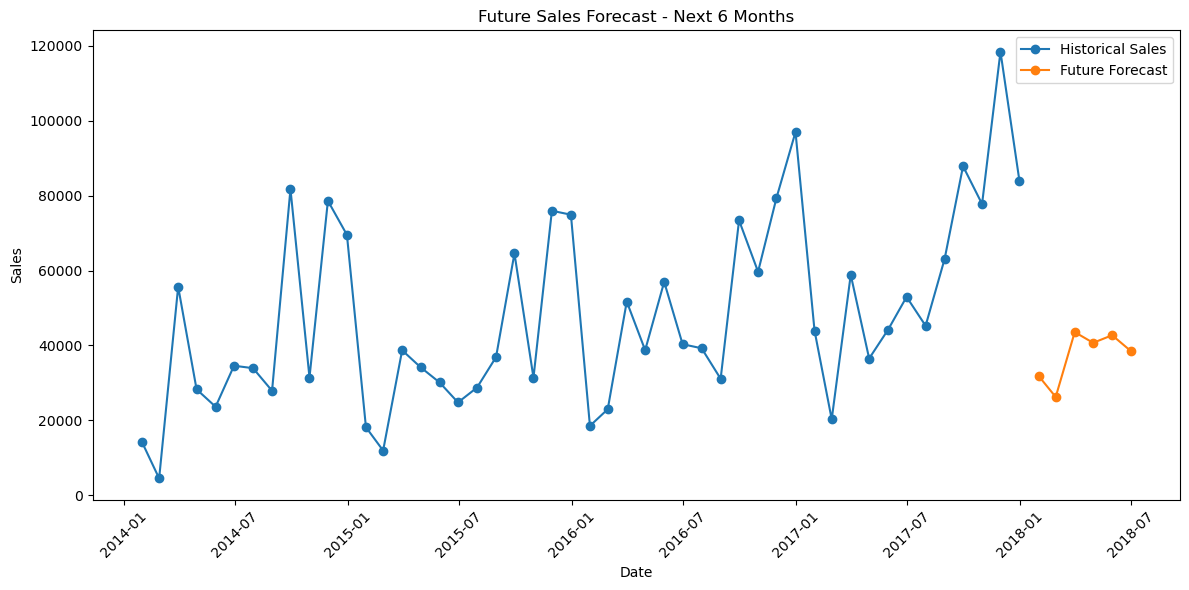

In [55]:
plt.figure(figsize=(12, 6))

# Historical sales
plt.plot(
    data['Order Date'],
    data['Sales'],
    marker='o',
    label='Historical Sales'
)

# Future predicted sales
plt.plot(
    future['Order Date'],
    future['Predicted Sales'],
    marker='o',
    label='Future Forecast'
)

plt.title("Future Sales Forecast - Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [56]:
first_prediction = future['Predicted Sales'].iloc[0]
last_prediction = future['Predicted Sales'].iloc[-1]

change = ((last_prediction - first_prediction) / first_prediction) * 100

print(f"Forecast change over 6 months: {change:.2f}%")

Forecast change over 6 months: 20.93%


In [57]:
future.to_csv(
    "future_sales_forecast.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


In [58]:
performance = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Value': [mae, rmse, r2]
})

performance

,Metric,Value
0,MAE,13009.848553
1,RMSE,15763.580706
2,R² Score,0.562332


In [59]:
forecast_table = future[['Order Date', 'Predicted Sales']].copy()

forecast_table['Predicted Sales'] = forecast_table['Predicted Sales'].round(2)

forecast_table

,Order Date,Predicted Sales
0,2018-01-31,31902.92
1,2018-02-28,26257.17
2,2018-03-31,43577.59
3,2018-04-30,40712.41
4,2018-05-31,42738.62
5,2018-06-30,38580.12


In [60]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
1,Month,0.774971
3,Time_Index,0.167731
2,Quarter,0.032519
0,Year,0.024779


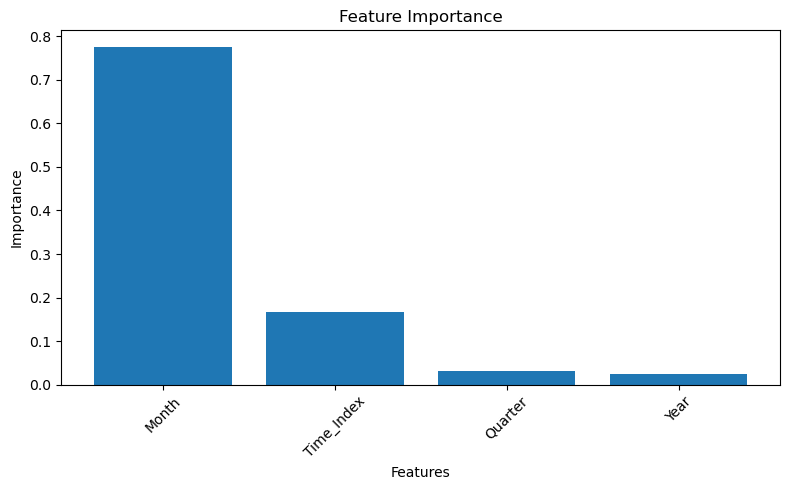

In [61]:
plt.figure(figsize=(8, 5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
future.to_csv(
    "future_sales_forecast.csv",
    index=False
)

performance.to_csv(
    "model_performance.csv",
    index=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("All results saved successfully!")

All results saved successfully!
